# Gaussian process regression

In [ ]:
import sys
import os

import numpy as np
import torch
import pandas as pd
import gpytorch

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load data and model

In [ ]:
X = pd.read_csv("../_temp/X.csv").drop(columns="Slurry")
y = pd.read_csv("../_temp/y.csv")
data = pd.concat([X, y], axis=1)

In [ ]:
from model.load import load_H_mean, load_phi_mean

H_Xscaler, H_yscaler, H_mean, H_likelihood, H_model = load_H_mean(device=device)
phi_Xscaler, phi_yscaler, phi_mean, phi_likelihood, phi_model = load_phi_mean(
    device=device
)

for module in H_Xscaler, H_yscaler, H_mean, H_likelihood, H_model:
    module.eval()
for module in phi_Xscaler, phi_yscaler, phi_mean, phi_likelihood, phi_model:
    module.eval()

## Plot

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

### Prior mean

In [ ]:
groups = list(data.groupby(["Cos_theta"]))
Rgts = data["Gap_to_thickness_ratio"]
Rgt_pred = np.linspace(Rgts.min(), Rgts.max(), 100)
Cas = data["Capillary_number"]

In [ ]:
ca_unique = np.sort(Cas.unique())
n_colors = len(ca_unique)
cmap = plt.get_cmap("viridis", n_colors)
norm = mcolors.BoundaryNorm(
    np.concatenate(
        [
            [ca_unique[0] * 0.9],
            (ca_unique[:-1] + ca_unique[1:]) / 2,
            [ca_unique[-1] * 1.1],
        ]
    ),
    ncolors=n_colors,
)

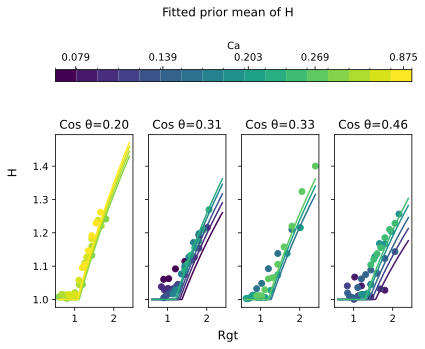

In [ ]:
fig, axes = plt.subplots(1, len(groups), sharex=True, sharey="row")
if len(groups) == 1:
    axes = [axes]

for ax, ((cos_theta,), df) in zip(axes, groups):

    for Ca, sub_df in df.groupby("Capillary_number", observed=True, as_index=False):
        color = cmap(norm(Ca))
        ax.scatter(sub_df["Gap_to_thickness_ratio"], sub_df["H"], color=color)

        X_pred = np.stack(
            [
                Rgt_pred,
                np.full_like(Rgt_pred, Ca),
                np.full_like(Rgt_pred, cos_theta),
            ],
            axis=-1,
        )

        with torch.no_grad():
            m = H_mean(torch.tensor(X_pred, dtype=torch.float32).to(device))
        ax.plot(Rgt_pred, m, color=color)

    ax.set_title(f"Cos θ={cos_theta:.2f}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes, orientation="horizontal", location="top", pad=0.2, aspect=30
)
cbar.set_label("Ca")
quartile_vals = np.quantile(Cas.values, [0, 0.25, 0.5, 0.75, 1.0])
nearest_cas = [ca_unique[np.argmin(np.abs(ca_unique - q))] for q in quartile_vals]
cbar.set_ticks([round(ca, 3) for ca in nearest_cas])
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())

fig.supxlabel("Rgt")
fig.supylabel("H")
fig.suptitle("Fitted prior mean of H")

plt.show()

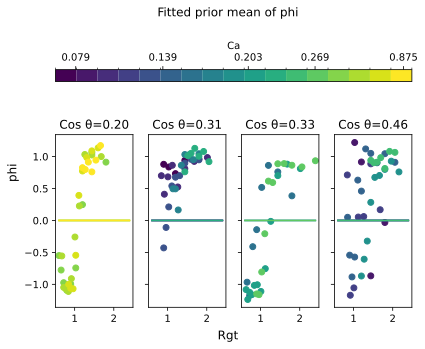

In [ ]:
fig, axes = plt.subplots(1, len(groups), sharex=True, sharey="row")
if len(groups) == 1:
    axes = [axes]

for ax, ((cos_theta,), df) in zip(axes, groups):

    for Ca, sub_df in df.groupby("Capillary_number", observed=True, as_index=False):
        color = cmap(norm(Ca))
        ax.scatter(sub_df["Gap_to_thickness_ratio"], sub_df["phi"], color=color)

        X_pred = np.stack(
            [
                Rgt_pred,
                np.full_like(Rgt_pred, Ca),
                np.full_like(Rgt_pred, cos_theta),
            ],
            axis=-1,
        )

        with torch.no_grad():
            m = phi_mean(torch.tensor(X_pred, dtype=torch.float32).to(device))
        ax.plot(Rgt_pred, m, color=color)

    ax.set_title(f"Cos θ={cos_theta:.2f}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes, orientation="horizontal", location="top", pad=0.2, aspect=30
)
cbar.set_label("Ca")
quartile_vals = np.quantile(Cas.values, [0, 0.25, 0.5, 0.75, 1.0])
nearest_cas = [ca_unique[np.argmin(np.abs(ca_unique - q))] for q in quartile_vals]
cbar.set_ticks([round(ca, 3) for ca in nearest_cas])
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())

fig.supxlabel("Rgt")
fig.supylabel("phi")
fig.suptitle("Fitted prior mean of phi")

plt.show()

### Box surface plot

In [ ]:
Rgt_min, Rgt_max = X["Gap_to_thickness_ratio"].min(), X["Gap_to_thickness_ratio"].max()
Ca_min, Ca_max = X["Capillary_number"].min(), X["Capillary_number"].max()
Ct_min, Ct_max = X["Cos_theta"].min(), X["Cos_theta"].max()

N = 50
CHUNK = 4096


def predict(Rgt_flat, Ca_flat, Ct_flat, x_scaler, y_scaler, mean, likelihood, model):
    """Return predicted mean on a flat array of inputs."""
    x_scaler.eval()
    y_scaler.eval()
    mean.eval()
    likelihood.eval()
    model.eval()

    X_raw = torch.tensor(
        np.column_stack([Rgt_flat, Ca_flat, Ct_flat]),
        dtype=torch.float32,
        device=device,
    )
    means = []
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for i in range(0, len(X_raw), CHUNK):
            X_pred = X_raw[i : i + CHUNK]
            X_scaled = x_scaler(X_pred)
            pred_scaled_res = model(X_scaled).mean
            pred_res = y_scaler.inverse_transform(pred_scaled_res)
            pred_mean = mean(X_pred)
            pred_y = pred_res + pred_mean
            means.append(pred_y.cpu().numpy())
    return np.concatenate(means)

In [ ]:
Rgt_1d = np.linspace(Rgt_min, Rgt_max, N)
Ca_1d = np.linspace(Ca_min, Ca_max, N)
Ct_1d = np.linspace(Ct_min, Ct_max, N)

Rgt_Ca_A, Rgt_Ca_B = np.meshgrid(Rgt_1d, Ca_1d, indexing="ij")
Ca_Ct_A, Ca_Ct_B = np.meshgrid(Ca_1d, Ct_1d, indexing="ij")
Rgt_Ct_A, Rgt_Ct_B = np.meshgrid(Rgt_1d, Ct_1d, indexing="ij")


def _get_face_val(arg1, arg2, arg3, zdir, offset):
    if zdir == "z":
        return arg3
    elif zdir == "x":
        return arg1
    else:
        return arg2

#### H

In [ ]:
H_faces = []
for ct in [Ct_min, Ct_max]:
    H = predict(
        Rgt_Ca_A.ravel(),
        Rgt_Ca_B.ravel(),
        np.full(N * N, ct),
        H_Xscaler,
        H_yscaler,
        H_mean,
        H_likelihood,
        H_model,
    ).reshape(N, N)
    H_faces.append((Rgt_Ca_A, Rgt_Ca_B, H, "z", ct))
for rgt in [Rgt_min, Rgt_max]:
    H = predict(
        np.full(N * N, rgt),
        Ca_Ct_A.ravel(),
        Ca_Ct_B.ravel(),
        H_Xscaler,
        H_yscaler,
        H_mean,
        H_likelihood,
        H_model,
    ).reshape(N, N)
    H_faces.append((H, Ca_Ct_A, Ca_Ct_B, "x", rgt))
for ca in [Ca_min, Ca_max]:
    H = predict(
        Rgt_Ct_A.ravel(),
        np.full(N * N, ca),
        Rgt_Ct_B.ravel(),
        H_Xscaler,
        H_yscaler,
        H_mean,
        H_likelihood,
        H_model,
    ).reshape(N, N)
    H_faces.append((Rgt_Ct_A, H, Rgt_Ct_B, "y", ca))

In [ ]:
H_all = np.concatenate([_get_face_val(*f).ravel() for f in H_faces])
vmin, vmax = H_all.min(), H_all.max()

n_color = 15
coolwarm = plt.cm.coolwarm
colors = [coolwarm(i / (n_color - 1)) for i in range(n_color)]
cmap = mcolors.ListedColormap(colors)
levels = np.linspace(vmin, vmax, n_color + 1)
norm = mcolors.BoundaryNorm(levels, cmap.N)

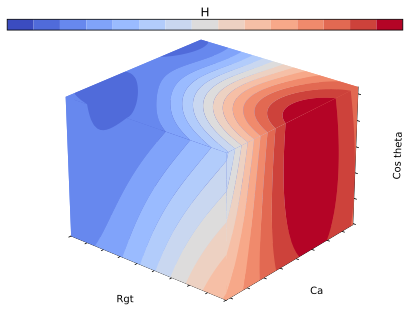

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_axes([0.02, 0.10, 0.82, 0.88], projection="3d")

for arg1, arg2, arg3, zdir, offset in H_faces:
    ax.contourf(
        arg1,
        arg2,
        arg3,
        zdir=zdir,
        offset=offset,
        levels=levels,
        cmap=cmap,
        norm=norm,
    )

ax.set_xlim(Rgt_min, Rgt_max)
ax.set_ylim(Ca_min, Ca_max)
ax.set_zlim(Ct_min, Ct_max)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlabel("Rgt")
ax.set_ylabel("Ca")
ax.set_zlabel("Cos theta")
ax.view_init(elev=25, azim=-50)

# Hide background panes and grid
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("none")
ax.yaxis.pane.set_edgecolor("none")
ax.zaxis.pane.set_edgecolor("none")
ax.grid(False)

# Colorbar (horizontal at top)
cbar_ax = fig.add_axes([0.15, 0.92, 0.55, 0.03])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", ticks=[])
cbar_ax.set_title("H", pad=3)
plt.show()

#### phi

In [ ]:
phi_faces = []
for ct in [Ct_min, Ct_max]:
    phi = predict(
        Rgt_Ca_A.ravel(),
        Rgt_Ca_B.ravel(),
        np.full(N * N, ct),
        phi_Xscaler,
        phi_yscaler,
        phi_mean,
        phi_likelihood,
        phi_model,
    ).reshape(N, N)
    phi_faces.append((Rgt_Ca_A, Rgt_Ca_B, phi, "z", ct))
for rgt in [Rgt_min, Rgt_max]:
    phi = predict(
        np.full(N * N, rgt),
        Ca_Ct_A.ravel(),
        Ca_Ct_B.ravel(),
        phi_Xscaler,
        phi_yscaler,
        phi_mean,
        phi_likelihood,
        phi_model,
    ).reshape(N, N)
    phi_faces.append((phi, Ca_Ct_A, Ca_Ct_B, "x", rgt))
for ca in [Ca_min, Ca_max]:
    phi = predict(
        Rgt_Ct_A.ravel(),
        np.full(N * N, ca),
        Rgt_Ct_B.ravel(),
        phi_Xscaler,
        phi_yscaler,
        phi_mean,
        phi_likelihood,
        phi_model,
    ).reshape(N, N)
    phi_faces.append((Rgt_Ct_A, phi, Rgt_Ct_B, "y", ca))

In [ ]:
phi_all = np.concatenate([_get_face_val(*f).ravel() for f in phi_faces])
vmin, vmax = phi_all.min(), phi_all.max()

n_color = 15
coolwarm = plt.cm.coolwarm
colors = [coolwarm(i / (n_color - 1)) for i in range(n_color)]
cmap = mcolors.ListedColormap(colors)
levels = np.linspace(vmin, vmax, n_color + 1)
norm = mcolors.BoundaryNorm(levels, cmap.N)

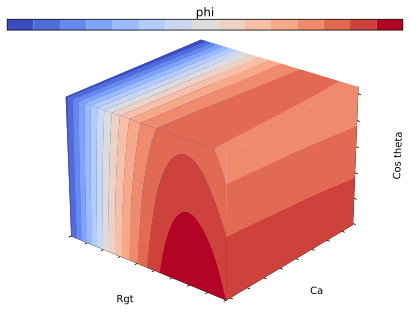

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_axes([0.02, 0.10, 0.82, 0.88], projection="3d")

for arg1, arg2, arg3, zdir, offset in phi_faces:
    ax.contourf(
        arg1,
        arg2,
        arg3,
        zdir=zdir,
        offset=offset,
        levels=levels,
        cmap=cmap,
        norm=norm,
    )

ax.set_xlim(Rgt_min, Rgt_max)
ax.set_ylim(Ca_min, Ca_max)
ax.set_zlim(Ct_min, Ct_max)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlabel("Rgt")
ax.set_ylabel("Ca")
ax.set_zlabel("Cos theta")
ax.view_init(elev=25, azim=-50)

# Hide background panes and grid
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("none")
ax.yaxis.pane.set_edgecolor("none")
ax.zaxis.pane.set_edgecolor("none")
ax.grid(False)

# Colorbar (horizontal at top)
cbar_ax = fig.add_axes([0.15, 0.92, 0.55, 0.03])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", ticks=[])
cbar_ax.set_title("phi", pad=3)
plt.show()

### Stacked surface plot

In [ ]:
Rgt_2d, Ca_2d = np.meshgrid(Rgt_1d, Ca_1d, indexing="ij")
cos_theta_vals = sorted(X["Cos_theta"].unique())

H_slices, phi_slices = [], []
for ct in cos_theta_vals:
    H_slice = predict(
        Rgt_2d.ravel(),
        Ca_2d.ravel(),
        np.full(N * N, ct),
        H_Xscaler,
        H_yscaler,
        H_mean,
        H_likelihood,
        H_model,
    ).reshape(N, N)
    phi_slice = predict(
        Rgt_2d.ravel(),
        Ca_2d.ravel(),
        np.full(N * N, ct),
        phi_Xscaler,
        phi_yscaler,
        phi_mean,
        phi_likelihood,
        phi_model,
    ).reshape(N, N)
    H_slices.append(H_slice)
    phi_slices.append(phi_slice)

#### H

In [ ]:
H_all = np.concatenate([h.ravel() for h in H_slices])
vmin, vmax = H_all.min(), H_all.max()

n_color = 15
coolwarm = plt.cm.coolwarm
colors = [coolwarm(i / (n_color - 1)) for i in range(n_color)]
cmap = mcolors.ListedColormap(colors)
levels = np.linspace(vmin, vmax, n_color + 1)
norm = mcolors.BoundaryNorm(levels, cmap.N)

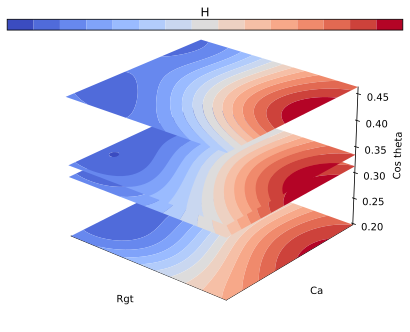

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_axes([0.02, 0.10, 0.82, 0.88], projection="3d")

for i_s, H_slice in enumerate(H_slices):
    zpos = cos_theta_vals[i_s]
    ax.contourf(
        Rgt_2d,
        Ca_2d,
        H_slice,
        zdir="z",
        offset=zpos,
        levels=levels,
        cmap=cmap,
        norm=norm,
    )

ax.set_xlim(Rgt_1d[0], Rgt_1d[-1])
ax.set_ylim(Ca_1d[0], Ca_1d[-1])
ax.set_zlim(cos_theta_vals[0], cos_theta_vals[-1])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("Rgt")
ax.set_ylabel("Ca")
ax.set_zlabel("Cos theta")
ax.view_init(elev=25, azim=-50)

# Hide background panes and grid
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("none")
ax.yaxis.pane.set_edgecolor("none")
ax.zaxis.pane.set_edgecolor("none")
ax.grid(False)

cbar_ax = fig.add_axes([0.15, 0.92, 0.55, 0.03])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", ticks=[])
cbar_ax.set_title("H", pad=3)
plt.show()

#### phi

In [ ]:
phi_all = np.concatenate([h.ravel() for h in phi_slices])
vmin, vmax = phi_all.min(), phi_all.max()

n_color = 15
coolwarm = plt.cm.coolwarm
colors = [coolwarm(i / (n_color - 1)) for i in range(n_color)]
cmap = mcolors.ListedColormap(colors)
levels = np.linspace(vmin, vmax, n_color + 1)
norm = mcolors.BoundaryNorm(levels, cmap.N)

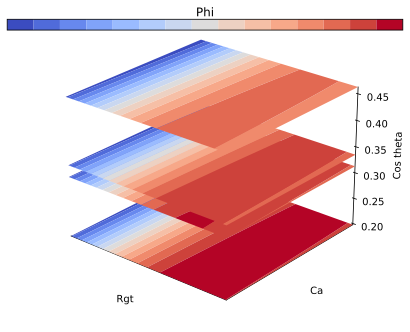

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_axes([0.02, 0.10, 0.82, 0.88], projection="3d")

for i_s, phi_slice in enumerate(phi_slices):
    zpos = cos_theta_vals[i_s]
    ax.contourf(
        Rgt_2d,
        Ca_2d,
        phi_slice,
        zdir="z",
        offset=zpos,
        levels=levels,
        cmap=cmap,
        norm=norm,
    )

ax.set_xlim(Rgt_1d[0], Rgt_1d[-1])
ax.set_ylim(Ca_1d[0], Ca_1d[-1])
ax.set_zlim(cos_theta_vals[0], cos_theta_vals[-1])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("Rgt")
ax.set_ylabel("Ca")
ax.set_zlabel("Cos theta")
ax.view_init(elev=25, azim=-50)

# Hide background panes and grid
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("none")
ax.yaxis.pane.set_edgecolor("none")
ax.zaxis.pane.set_edgecolor("none")
ax.grid(False)

cbar_ax = fig.add_axes([0.15, 0.92, 0.55, 0.03])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", ticks=[])
cbar_ax.set_title("Phi", pad=3)
plt.show()